Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 72s 194ms/step - accuracy: 0.5291 - loss: 1.1130 - val_accuracy: 0.5292 - val_loss: 1.0900
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.8227 - loss: 0.5071 - val_accuracy: 0.5710 - val_loss: 0.9725
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 54s 171ms/step - accuracy: 0.9028 - loss: 0.3115 - val_accuracy: 0.5911 - val_loss: 0.9614
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 52s 168ms/step - accuracy: 0.9458 - loss: 0.1913 - val_accuracy: 0.6188 - val_loss: 0.8779
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 49s 156ms/step - accuracy: 0.9734 - loss: 0.1248 - val_accuracy: 0.6329 - val_loss: 0.9005
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 49s 158ms/step - accuracy: 0.9807 - loss: 0.0874 - val_accuracy: 0.5983 - val_loss: 1.1439
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.9910 - loss: 0.0557 - val_accuracy: 0.6462 - val_loss: 1.0223

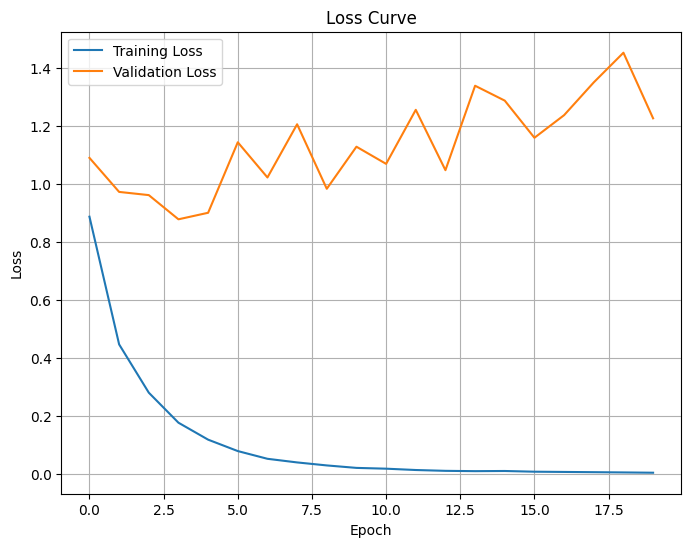

78/78 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step


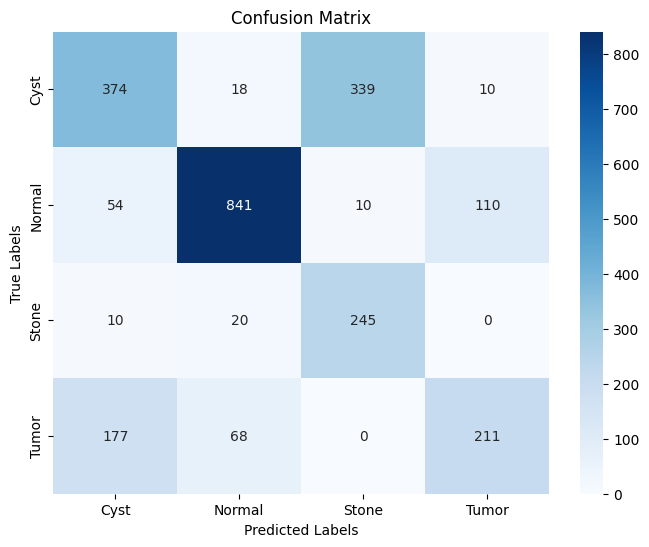

Training Time: 1013.03 seconds
Testing Time: 16.37 seconds
Confusion Matrix:
 [[374  18 339  10]
 [ 54 841  10 110]
 [ 10  20 245   0]
 [177  68   0 211]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.61      0.50      0.55       741
      Normal       0.89      0.83      0.86      1015
       Stone       0.41      0.89      0.56       275
       Tumor       0.64      0.46      0.54       456

    accuracy                           0.67      2487
   macro avg       0.64      0.67      0.63      2487
weighted avg       0.71      0.67      0.67      2487

Overall Accuracy: 0.6719
Accuracy for class 'Cyst': 0.5047
Accuracy for class 'Normal': 0.8286
Accuracy for class 'Stone': 0.8909
Accuracy for class 'Tumor': 0.4627


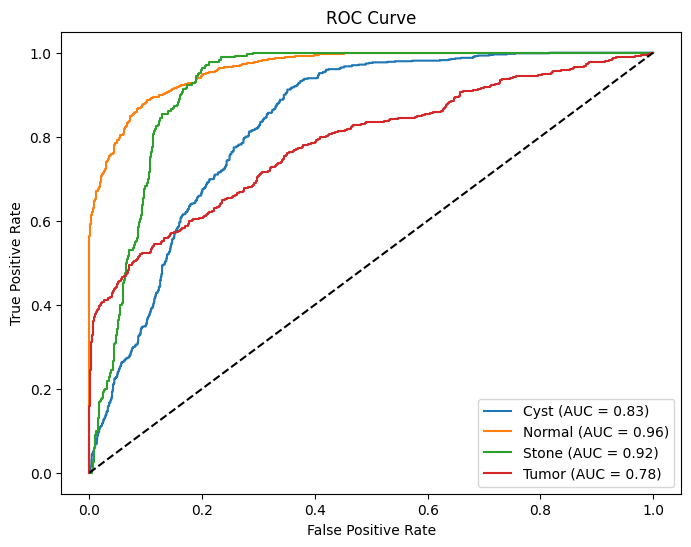

Overall Accuracy: 67.19%
Precision: 63.65%
Recall: 67.17%
F1-Score: 62.72%


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import time
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 20
DATASET_PATH = "/kaggle/input/datasets/nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone" 

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

training_time = time.time() - start_train_time

start_test_time = time.time()

y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


accuracy = np.sum(y_pred_classes == y_true) / len(y_true)


precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

# Print results
print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")